In [2]:
!pip install -q langchain langchain-text-splitters tiktoken pypdf fpdf2

In [3]:
import os

os.makedirs("docs", exist_ok=True)

article_text = """
Generative Artificial Intelligence

Generative AI is a branch of artificial intelligence that can create
new content such as text, images, audio, video, and computer code.
Unlike traditional AI systems that mainly analyze existing data,
generative AI can produce new content based on patterns learned from
large datasets.

Large Language Models

Large Language Models, also known as LLMs, are machine learning models
trained on large amounts of text data. They can understand questions,
generate text, summarize information, translate languages, and assist
with programming tasks.

Transformers

Transformers are neural network architectures widely used in modern
language models. They use an attention mechanism to understand the
relationship between different words in a sequence. Transformers have
become an important foundation for many modern language models.

Prompt Engineering

Prompt engineering is the process of designing effective instructions
for an AI model. A well-designed prompt can provide the model with
clear context, instructions, constraints, and the expected output
format. Good prompts can improve the quality and usefulness of AI
responses.

Retrieval Augmented Generation

Retrieval Augmented Generation, or RAG, combines information retrieval
with language generation. Instead of depending only on the knowledge
stored inside a language model, RAG retrieves relevant information from
external documents and provides that information to the language model
as context.

Document Chunking

Document chunking is the process of dividing a large document into
smaller pieces called chunks. Chunking is important in RAG systems
because smaller chunks can be efficiently converted into embeddings,
stored in a vector database, and retrieved when a user asks a question.

Embeddings

Embeddings are numerical representations of text. Text with similar
meaning is represented by vectors that are close to each other in the
embedding space. Embeddings allow RAG systems to perform semantic
similarity searches.

Vector Databases

Vector databases are specialized databases designed to store and
search vector embeddings efficiently. In a RAG system, document chunks
are converted into embeddings and stored in a vector database. When a
user asks a question, the system searches for the most relevant chunks.

RAG Workflow

A typical RAG system first loads documents, divides them into chunks,
creates embeddings for those chunks, and stores them in a vector
database. When a user submits a query, the query is also converted into
an embedding. The system retrieves the most relevant document chunks
and provides them to a language model to generate the final response.
"""

with open("docs/genai_rag_article.txt", "w") as f:
    f.write(article_text)

print("Document created: docs/genai_rag_article.txt")
print("Total characters:", len(article_text))
print("Total words:", len(article_text.split()))

Document created: docs/genai_rag_article.txt
Total characters: 2686
Total words: 390


In [4]:
with open("docs/genai_rag_article.txt", "r") as f:
    loaded_text = f.read()

print("Loaded document preview:\n")
print(loaded_text[:500], "...")

Loaded document preview:


Generative Artificial Intelligence

Generative AI is a branch of artificial intelligence that can create
new content such as text, images, audio, video, and computer code.
Unlike traditional AI systems that mainly analyze existing data,
generative AI can produce new content based on patterns learned from
large datasets.

Large Language Models

Large Language Models, also known as LLMs, are machine learning models
trained on large amounts of text data. They can understand questions,
generate tex ...


Creating PDF

In [5]:
from fpdf import FPDF

pdf = FPDF()
pdf.add_page()
pdf.set_font("Times", size=12)

for line in article_text.split("\n"):
    pdf.multi_cell(190, 8, line)

pdf.output("docs/genai_rag_article.pdf")

print("PDF created: docs/genai_rag_article.pdf")

PDF created: docs/genai_rag_article.pdf


Read PDF

In [6]:
from pypdf import PdfReader

reader = PdfReader("docs/genai_rag_article.pdf")

pdf_text = ""

for page in reader.pages:
    pdf_text += page.extract_text() + "\n"

print("Pages found:", len(reader.pages))

print("\nExtracted PDF text preview:\n")
print(pdf_text[:500], "...")

Pages found: 3

Extracted PDF text preview:

Generative Artificial Intelligence
Generative AI is a branch of artificial intelligence that can create
new content such as text, images, audio, video, and computer code.
Unlike traditional AI systems that mainly analyze existing data,
generative AI can produce new content based on patterns learned from
large datasets.
Large Language Models
Large Language Models, also known as LLMs, are machine learning models
trained on large amounts of text data. They can understand questions,
generate text, s ...


CHUNKING STRATEGIES


In [7]:
def fixed_size_chunking(text, chunk_size=300, overlap=50):
    chunks = []
    start = 0

    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap

    return chunks


fixed_chunks = fixed_size_chunking(
    loaded_text,
    chunk_size=300,
    overlap=50
)

print("Number of chunks:", len(fixed_chunks))

print("\n--- Chunk 1 ---\n")
print(fixed_chunks[0])

print("\n--- Chunk 2 ---\n")
print(fixed_chunks[1])

Number of chunks: 11

--- Chunk 1 ---


Generative Artificial Intelligence

Generative AI is a branch of artificial intelligence that can create
new content such as text, images, audio, video, and computer code.
Unlike traditional AI systems that mainly analyze existing data,
generative AI can produce new content based on patterns learne

--- Chunk 2 ---

I can produce new content based on patterns learned from
large datasets.

Large Language Models

Large Language Models, also known as LLMs, are machine learning models
trained on large amounts of text data. They can understand questions,
generate text, summarize information, translate languages, and


Character Based Chunking

In [8]:
from langchain_text_splitters import CharacterTextSplitter

char_splitter = CharacterTextSplitter(
    separator="\n\n",
    chunk_size=300,
    chunk_overlap=50
)

char_chunks = char_splitter.split_text(loaded_text)

print("Number of chunks:", len(char_chunks))

for i, chunk in enumerate(char_chunks):
    print(f"\n--- Chunk {i+1} ({len(chunk)} chars) ---")
    print(chunk)

Number of chunks: 12

--- Chunk 1 (34 chars) ---
Generative Artificial Intelligence

--- Chunk 2 (285 chars) ---
Generative AI is a branch of artificial intelligence that can create
new content such as text, images, audio, video, and computer code.
Unlike traditional AI systems that mainly analyze existing data,
generative AI can produce new content based on patterns learned from
large datasets.

--- Chunk 3 (271 chars) ---
Large Language Models

Large Language Models, also known as LLMs, are machine learning models
trained on large amounts of text data. They can understand questions,
generate text, summarize information, translate languages, and assist
with programming tasks.

Transformers

--- Chunk 4 (282 chars) ---
Transformers

Transformers are neural network architectures widely used in modern
language models. They use an attention mechanism to understand the
relationship between different words in a sequence. Transformers have
become an important foundation for many modern langu

Recursive Character Chunking

In [9]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""]
)

recursive_chunks = recursive_splitter.split_text(loaded_text)

print("Number of chunks:", len(recursive_chunks))

for i, chunk in enumerate(recursive_chunks):
    print(f"\n--- Chunk {i+1} ({len(chunk)} chars) ---")
    print(chunk)

Number of chunks: 14

--- Chunk 1 (34 chars) ---
Generative Artificial Intelligence

--- Chunk 2 (285 chars) ---
Generative AI is a branch of artificial intelligence that can create
new content such as text, images, audio, video, and computer code.
Unlike traditional AI systems that mainly analyze existing data,
generative AI can produce new content based on patterns learned from
large datasets.

--- Chunk 3 (271 chars) ---
Large Language Models

Large Language Models, also known as LLMs, are machine learning models
trained on large amounts of text data. They can understand questions,
generate text, summarize information, translate languages, and assist
with programming tasks.

Transformers

--- Chunk 4 (282 chars) ---
Transformers

Transformers are neural network architectures widely used in modern
language models. They use an attention mechanism to understand the
relationship between different words in a sequence. Transformers have
become an important foundation for many modern langu

Sentence Chunking

In [10]:
import re

def sentence_chunking(text, sentences_per_chunk=3):
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())

    chunks = []

    for i in range(0, len(sentences), sentences_per_chunk):
        chunk = " ".join(sentences[i:i + sentences_per_chunk])
        chunks.append(chunk)

    return chunks


sentence_chunks = sentence_chunking(
    loaded_text,
    sentences_per_chunk=3
)

print("Number of chunks:", len(sentence_chunks))

for i, chunk in enumerate(sentence_chunks):
    print(f"\n--- Chunk {i+1} ---")
    print(chunk)

Number of chunks: 8

--- Chunk 1 ---
Generative Artificial Intelligence

Generative AI is a branch of artificial intelligence that can create
new content such as text, images, audio, video, and computer code. Unlike traditional AI systems that mainly analyze existing data,
generative AI can produce new content based on patterns learned from
large datasets. Large Language Models

Large Language Models, also known as LLMs, are machine learning models
trained on large amounts of text data.

--- Chunk 2 ---
They can understand questions,
generate text, summarize information, translate languages, and assist
with programming tasks. Transformers

Transformers are neural network architectures widely used in modern
language models. They use an attention mechanism to understand the
relationship between different words in a sequence.

--- Chunk 3 ---
Transformers have
become an important foundation for many modern language models. Prompt Engineering

Prompt engineering is the process of designing

Token Based Chunking

In [11]:
from langchain_text_splitters import TokenTextSplitter

token_splitter = TokenTextSplitter(
    chunk_size=100,
    chunk_overlap=20
)

token_chunks = token_splitter.split_text(loaded_text)

print("Number of chunks:", len(token_chunks))

for i, chunk in enumerate(token_chunks):
    print(f"\n--- Chunk {i+1} ---")
    print(chunk)

Number of chunks: 7

--- Chunk 1 ---

Generative Artificial Intelligence

Generative AI is a branch of artificial intelligence that can create
new content such as text, images, audio, video, and computer code.
Unlike traditional AI systems that mainly analyze existing data,
generative AI can produce new content based on patterns learned from
large datasets.

Large Language Models

Large Language Models, also known as LLMs, are machine learning models
trained on large amounts of text data. They can understand questions,


--- Chunk 2 ---
, are machine learning models
trained on large amounts of text data. They can understand questions,
generate text, summarize information, translate languages, and assist
with programming tasks.

Transformers

Transformers are neural network architectures widely used in modern
language models. They use an attention mechanism to understand the
relationship between different words in a sequence. Transformers have
become an important foundation for many mod

Comparing No.of Chunks

In [12]:
print("Chunking Strategy Comparison")
print("-----------------------------")

print("Fixed-size chunks:", len(fixed_chunks))
print("Character chunks:", len(char_chunks))
print("Recursive chunks:", len(recursive_chunks))
print("Sentence chunks:", len(sentence_chunks))
print("Token chunks:", len(token_chunks))

Chunking Strategy Comparison
-----------------------------
Fixed-size chunks: 11
Character chunks: 12
Recursive chunks: 14
Sentence chunks: 8
Token chunks: 7


Comparing Chunk Sizes

In [13]:
strategies = {
    "Fixed Size": fixed_chunks,
    "Character": char_chunks,
    "Recursive": recursive_chunks,
    "Sentence": sentence_chunks,
    "Token": token_chunks
}

for name, chunks in strategies.items():

    sizes = [len(chunk) for chunk in chunks]

    print(f"\n{name}")
    print("Number of chunks:", len(chunks))
    print("Average chunk size:", round(sum(sizes) / len(sizes), 2))
    print("Minimum chunk size:", min(sizes))
    print("Maximum chunk size:", max(sizes))


Fixed Size
Number of chunks: 11
Average chunk size: 289.64
Minimum chunk size: 186
Maximum chunk size: 300

Character
Number of chunks: 12
Average chunk size: 224.5
Minimum chunk size: 12
Maximum chunk size: 345

Recursive
Number of chunks: 14
Average chunk size: 192.21
Minimum chunk size: 12
Maximum chunk size: 295

Sentence
Number of chunks: 8
Average chunk size: 333.62
Minimum chunk size: 200
Maximum chunk size: 454

Token
Number of chunks: 7
Average chunk size: 464.43
Minimum chunk size: 361
Maximum chunk size: 520


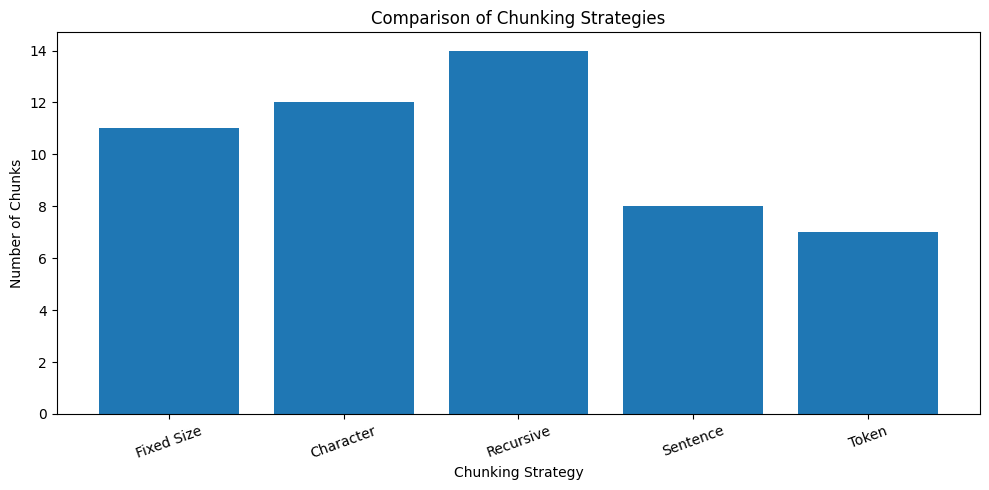

In [14]:
import matplotlib.pyplot as plt

strategy_names = list(strategies.keys())
chunk_counts = [len(strategies[name]) for name in strategy_names]

plt.figure(figsize=(10, 5))

plt.bar(strategy_names, chunk_counts)

plt.xlabel("Chunking Strategy")
plt.ylabel("Number of Chunks")
plt.title("Comparison of Chunking Strategies")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Observations

- Fixed-size chunking divides the document based on character positions.
- Character chunking uses a specified separator to divide the document.
- Recursive chunking tries multiple separators to preserve meaningful text structure.
- Sentence chunking keeps complete sentences together.
- Token chunking divides the document based on tokens.

For RAG systems, the choice of chunking strategy can affect retrieval
quality because the retrieved chunks should contain enough meaningful
context for the language model.